# Engine Size vs. Price: Linear Regression

We'll use `scikit-learn` to fit a simple linear regression model predicting a car's **price** from its **engine size** (`enginesize`), using the `cars.csv` dataset. Along the way we'll split the data into train/test sets and look at **R²** (the coefficient of determination) to see how well the model fits.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

## Load the Data

Read `cars.csv` and take a quick peek to confirm the `enginesize` and `price` columns are there.

In [2]:
df = pd.read_csv("cars.csv")
df[["enginesize", "price"]].head()

,enginesize,price
0,130,13495.0
1,130,16500.0
2,152,16500.0
3,109,13950.0
4,136,17450.0


## Train/Test Split

We hold out 20% of the data as a test set so we can check how well the model generalizes to data it hasn't seen. `random_state=42` just makes the split reproducible.

In [3]:
X = df[["enginesize"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 164, Test rows: 41


## Fit the Linear Regression Model

Fit `LinearRegression` on the training data only.

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"price = {slope:.2f} * enginesize + {intercept:.2f}")

price = 165.84 * enginesize + -7741.77


## R² (Coefficient of Determination)

**R²** tells us what proportion of the variance in `price` is explained by `enginesize`. It ranges from 0 to 1 (can be negative for a very bad fit):

- **R² = 1** → the model explains all the variability in the data (perfect fit).
- **R² = 0** → the model explains none of it (no better than just predicting the mean price).

We'll compute R² on both the training set (how well it fits the data it learned from) and the test set (how well it generalizes to new, unseen data).

In [5]:
train_r2 = model.score(X_train, y_train)

y_pred_test = model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Train R^2: {train_r2:.3f}")
print(f"Test R^2:  {test_r2:.3f}")

Train R^2: 0.751
Test R^2:  0.804


## Visualize the Fit

Scatter the actual train/test points, draw the fitted regression line across the range of engine sizes, and annotate the plot with the test R² value.

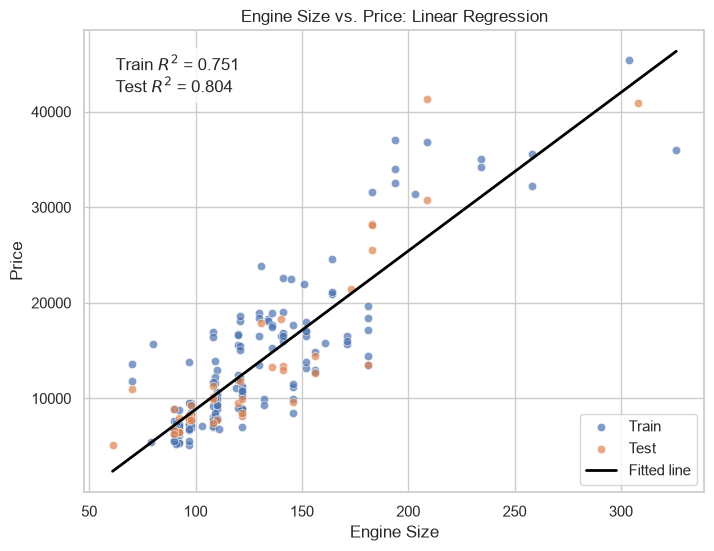

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(x=X_train["enginesize"], y=y_train, label="Train", ax=ax, alpha=0.7)
sns.scatterplot(x=X_test["enginesize"], y=y_test, label="Test", ax=ax, alpha=0.7)

# Draw the regression line across the full range of engine sizes
x_line = np.linspace(X["enginesize"].min(), X["enginesize"].max(), 100).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(x_line, columns=["enginesize"]))
ax.plot(x_line, y_line, color="black", linewidth=2, label="Fitted line")

ax.set_xlabel("Engine Size")
ax.set_ylabel("Price")
ax.set_title("Engine Size vs. Price: Linear Regression")
ax.legend()

# Annotate R^2 directly on the plot
ax.text(
    0.05, 0.95,
    f"Train $R^2$ = {train_r2:.3f}\nTest $R^2$ = {test_r2:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.show()